06 Ablation 4: Feature Count Comparison
이 코드는 UNSW-NB15 multiclass intrusion detection 프로젝트에서
feature 개수가 많을수록 Average Attack-Class Recall이 좋아지는지 확인하는 실험입니다.
고정 조건:
- Ablation 1 최종 선택: Capped_SMOTENC_50k
- Ablation 2 최종 선택: Ordinal Encoding
- Ablation 3 최종 선택: Average Attack-Class Recall 기준 최적 Feature Selection 방법
- Model: RandomForestClassifier
비교 조건:
- ALL 43 features
- Top 40
- Top 30
- Top 20
- Top 10
Primary metric:
- Average Attack-Class Recall
Secondary metric:
- Macro F1

In [1]:
# Ablation 4: Feature 개수 비교
# 고정 조건:
# - Class imbalance strategy: SMOTENC
# - Encoding strategy: Ordinal Encoding
# - Feature selection method: Ablation 3에서 선택된 방법

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

from imblearn.over_sampling import SMOTENC

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("..")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "data" / "outputs"
REPORT_DIR = PROJECT_ROOT / "reports"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

NOMINAL_CATEGORICAL_COLS = [
    "proto",
    "state",
    "service",
]

NUMERIC_LIKE_COLS = [
    "sport",
    "dsport",
    "ct_ftp_cmd",
]

NORMAL_LABEL = "Normal"

PRIMARY_METRIC = "average_attack_recall"
SECONDARY_METRIC = "macro_f1"

FEATURE_COUNT_CONDITIONS = {
    "ALL_43": None,
    "Top_40": 40,
    "Top_30": 30,
    "Top_20": 20,
    "Top_10": 10,
}

In [2]:
X_train = pd.read_csv(PROCESSED_DIR / "X_train_baseline.csv")
X_test = pd.read_csv(PROCESSED_DIR / "X_test_baseline.csv")
y_train = pd.read_csv(PROCESSED_DIR / "y_train_baseline.csv").squeeze()
y_test = pd.read_csv(PROCESSED_DIR / "y_test_baseline.csv").squeeze()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)
print("Number of features:", X_train.shape[1])

X_train: (2032037, 43)
X_test : (508010, 43)
y_train: (2032037,)
y_test : (508010,)
Number of features: 43


In [3]:
ablation1_config_path = OUTPUT_DIR / "ablation1_best_config.json"
ablation2_config_path = OUTPUT_DIR / "ablation2_best_config.json"

with open(ablation1_config_path, "r") as f:
    ablation1_config = json.load(f)

with open(ablation2_config_path, "r") as f:
    ablation2_config = json.load(f)

BEST_IMBALANCE_STRATEGY = ablation1_config["best_strategy"]
BEST_ENCODING = ablation2_config["best_encoding"]
OVERSAMPLE_CAP_VALUE = int(ablation1_config.get("oversample_cap_value", 50_000))

assert BEST_IMBALANCE_STRATEGY == "Capped_SMOTENC_50k", (
    f"Expected Capped_SMOTENC_50k, got {BEST_IMBALANCE_STRATEGY}"
)

assert BEST_ENCODING == "Ordinal Encoding", (
    f"Expected Ordinal Encoding, got {BEST_ENCODING}"
)

print("Best imbalance strategy:", BEST_IMBALANCE_STRATEGY)
print("Best encoding strategy:", BEST_ENCODING)
print("Oversample cap value:", OVERSAMPLE_CAP_VALUE)

Best imbalance strategy: Capped_SMOTENC_50k
Best encoding strategy: Ordinal Encoding
Oversample cap value: 50000


In [4]:
selection_summary = pd.read_csv(
    OUTPUT_DIR / "ablation3_feature_selection_summary.csv"
)

selection_results = pd.read_csv(
    OUTPUT_DIR / "ablation3_feature_selection_results.csv"
)

display(selection_summary)
display(selection_results.head())

,method,avg_attack_recall,macro_f1
0,Random Forest Importance,0.607030,0.601391
1,Mutual Information,0.610758,0.598003
2,Permutation Importance,0.605004,0.608550


,method,class,recall,f1_score
0,Random Forest Importance,Analysis,0.198131,0.123832
1,Random Forest Importance,Backdoor,0.118026,0.073875
2,Random Forest Importance,DoS,0.538979,0.419313
3,Random Forest Importance,Exploits,0.609882,0.687512
4,Random Forest Importance,Fuzzers,0.666529,0.662770


In [5]:
def find_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col

    raise ValueError(f"None of these columns exist: {candidates}")


summary_method_col = find_column(
    selection_summary,
    [
        "feature_selection_method",
        "method",
        "selection_method",
        "feature_selector",
    ],
)

summary_recall_col = find_column(
    selection_summary,
    [
        "average_attack_recall",
        "average_attack_class_recall",
        "avg_attack_recall",
    ],
)

summary_macro_f1_col = find_column(
    selection_summary,
    [
        "macro_f1",
        "macro_f1_score",
        "Macro F1",
    ],
)

best_selection_row = (
    selection_summary
    .sort_values(
        by=[summary_recall_col, summary_macro_f1_col],
        ascending=[False, False]
    )
    .iloc[0]
)

BEST_FEATURE_SELECTION_METHOD = best_selection_row[summary_method_col]

print("Best feature selection method:", BEST_FEATURE_SELECTION_METHOD)
print("Average Attack-Class Recall:", best_selection_row[summary_recall_col])
print("Macro F1:", best_selection_row[summary_macro_f1_col])

Best feature selection method: Mutual Information
Average Attack-Class Recall: 0.6107579607256908
Macro F1: 0.5980029501717252


In [6]:
def clean_numeric_like_columns(X_train_input, X_test_input, numeric_like_cols):
    X_train_clean = X_train_input.copy()
    X_test_clean = X_test_input.copy()

    for col in numeric_like_cols:
        if col in X_train_clean.columns:
            X_train_clean[col] = pd.to_numeric(
                X_train_clean[col],
                errors="coerce"
            )
            X_test_clean[col] = pd.to_numeric(
                X_test_clean[col],
                errors="coerce"
            )

            train_mean = X_train_clean[col].mean()

            X_train_clean[col] = X_train_clean[col].fillna(train_mean)
            X_test_clean[col] = X_test_clean[col].fillna(train_mean)

    return X_train_clean, X_test_clean


def apply_ordinal_encoding(X_train_input, X_test_input, categorical_cols):
    X_train_encoded = X_train_input.copy()
    X_test_encoded = X_test_input.copy()

    active_categorical_cols = [
        col for col in categorical_cols
        if col in X_train_encoded.columns
    ]

    if len(active_categorical_cols) == 0:
        return X_train_encoded, X_test_encoded

    encoder = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )

    X_train_encoded[active_categorical_cols] = encoder.fit_transform(
        X_train_encoded[active_categorical_cols].astype(str)
    )

    X_test_encoded[active_categorical_cols] = encoder.transform(
        X_test_encoded[active_categorical_cols].astype(str)
    )

    return X_train_encoded, X_test_encoded


def preprocess_fixed_pipeline(X_train_input, X_test_input):
    X_train_proc, X_test_proc = clean_numeric_like_columns(
        X_train_input,
        X_test_input,
        NUMERIC_LIKE_COLS
    )

    X_train_proc, X_test_proc = apply_ordinal_encoding(
        X_train_proc,
        X_test_proc,
        NOMINAL_CATEGORICAL_COLS
    )

    return X_train_proc, X_test_proc

In [7]:
def make_capped_sampling_strategy(y, cap_value):
    class_counts = y.value_counts()
    majority_class = class_counts.idxmax()
    second_largest = int(class_counts.sort_values(ascending=False).iloc[1])

    oversample_target = min(second_largest, cap_value)

    sampling_strategy = {
        cls: oversample_target
        for cls, count in class_counts.items()
        if cls != majority_class and count < oversample_target
    }

    return sampling_strategy, oversample_target


def apply_capped_smotenc(X_train_input, y_train_input, categorical_cols, cap_value):
    active_categorical_cols = [
        col for col in categorical_cols
        if col in X_train_input.columns
    ]

    categorical_indices = [
        X_train_input.columns.get_loc(col)
        for col in active_categorical_cols
    ]

    sampling_strategy, oversample_target = make_capped_sampling_strategy(
        y_train_input,
        cap_value
    )

    min_count = int(y_train_input.value_counts().min())
    k_neighbors = min(5, min_count - 1)

    smotenc = SMOTENC(
        categorical_features=categorical_indices,
        sampling_strategy=sampling_strategy,
        random_state=RANDOM_STATE,
        k_neighbors=k_neighbors
    )

    X_resampled, y_resampled = smotenc.fit_resample(
        X_train_input,
        y_train_input
    )

    print("SMOTENC oversample target:", oversample_target)
    print("Sampling strategy:", sampling_strategy)

    return X_resampled, y_resampled

In [8]:
def average_attack_class_recall(y_true, y_pred, normal_label=NORMAL_LABEL):
    report = classification_report(
        y_true,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    attack_recalls = []

    for label, metrics in report.items():
        if label in [normal_label, "accuracy", "macro avg", "weighted avg"]:
            continue

        attack_recalls.append(metrics["recall"])

    return float(np.mean(attack_recalls))


def count_attacks_predicted_as_normal(y_true, y_pred, normal_label=NORMAL_LABEL):
    y_true_array = np.asarray(y_true)
    y_pred_array = np.asarray(y_pred)

    return int(
        np.sum(
            (y_true_array != normal_label)
            & (y_pred_array == normal_label)
        )
    )


def evaluate_predictions(y_true, y_pred):
    return {
        "average_attack_recall": average_attack_class_recall(y_true, y_pred),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "attacks_predicted_as_normal": count_attacks_predicted_as_normal(
            y_true,
            y_pred
        ),
    }

In [9]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance

X_train_rank_proc, X_test_rank_proc = preprocess_fixed_pipeline(
    X_train,
    X_test
)

X_train_rank_resampled, y_train_rank_resampled = apply_capped_smotenc(
    X_train_rank_proc,
    y_train,
    NOMINAL_CATEGORICAL_COLS,
    OVERSAMPLE_CAP_VALUE
)

if BEST_FEATURE_SELECTION_METHOD == "Mutual Information":
    scores = mutual_info_classif(
        X_train_rank_resampled,
        y_train_rank_resampled,
        random_state=RANDOM_STATE
    )

    ranked_features_df = (
        pd.DataFrame({
            "feature": X_train_rank_resampled.columns,
            "score": scores
        })
        .sort_values("score", ascending=False)
        .reset_index(drop=True)
    )

elif BEST_FEATURE_SELECTION_METHOD == "Random Forest Importance":
    selector_model = RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight=None
    )

    selector_model.fit(X_train_rank_resampled, y_train_rank_resampled)

    ranked_features_df = (
        pd.DataFrame({
            "feature": X_train_rank_resampled.columns,
            "score": selector_model.feature_importances_
        })
        .sort_values("score", ascending=False)
        .reset_index(drop=True)
    )

elif BEST_FEATURE_SELECTION_METHOD == "Permutation Importance":
    sample_size = min(30_000, len(X_train_rank_resampled))

    X_perm_sample = X_train_rank_resampled.sample(
        n=sample_size,
        random_state=RANDOM_STATE
    )
    y_perm_sample = y_train_rank_resampled.loc[X_perm_sample.index]

    selector_model = RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight=None
    )

    selector_model.fit(X_perm_sample, y_perm_sample)

    perm_result = permutation_importance(
        selector_model,
        X_perm_sample,
        y_perm_sample,
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scoring="recall_macro"
    )

    ranked_features_df = (
        pd.DataFrame({
            "feature": X_perm_sample.columns,
            "score": perm_result.importances_mean
        })
        .sort_values("score", ascending=False)
        .reset_index(drop=True)
    )

else:
    raise ValueError(
        f"Unsupported feature selection method: {BEST_FEATURE_SELECTION_METHOD}"
    )

ranked_features = ranked_features_df["feature"].tolist()

print("Feature selection method:", BEST_FEATURE_SELECTION_METHOD)
print("Number of ranked features:", len(ranked_features))
print("Top 10 ranked features:", ranked_features[:10])

display(ranked_features_df.head(40))

SMOTENC oversample target: 50000
Sampling strategy: {'Exploits': 50000, 'Fuzzers': 50000, 'DoS': 50000, 'Reconnaissance': 50000, 'Analysis': 50000, 'Backdoor': 50000, 'Shellcode': 50000, 'Worms': 50000}


Feature selection method: Mutual Information
Number of ranked features: 43
Top 10 ranked features: ['sbytes', 'sload', 'sttl', 'smeansz', 'ct_state_ttl', 'dsport', 'dttl', 'dbytes', 'proto', 'dmeansz']


,feature,score
0,sbytes,0.780902
1,sload,0.643196
2,sttl,0.629371
3,smeansz,0.599187
4,ct_state_ttl,0.561552
5,dsport,0.514782
6,dttl,0.506879
7,dbytes,0.469389
8,proto,0.436121
9,dmeansz,0.418250


In [10]:
def get_selected_features(condition_name, top_n):
    if top_n is None:
        return list(X_train.columns)

    if len(ranked_features) < top_n:
        raise ValueError(
            f"{condition_name} requires {top_n} features, "
            f"but only {len(ranked_features)} ranked features are available."
        )

    return ranked_features[:top_n]

In [11]:
results = []

for condition_name, top_n in FEATURE_COUNT_CONDITIONS.items():
    print("=" * 80)
    print("Running condition:", condition_name)

    selected_features = get_selected_features(condition_name, top_n)

    X_train_subset = X_train[selected_features].copy()
    X_test_subset = X_test[selected_features].copy()

    X_train_proc, X_test_proc = preprocess_fixed_pipeline(
        X_train_subset,
        X_test_subset
    )

    active_smotenc_categorical_cols = [
        col for col in NOMINAL_CATEGORICAL_COLS
        if col in X_train_proc.columns
    ]

    X_train_resampled, y_train_resampled = apply_capped_smotenc(
        X_train_proc,
        y_train,
        active_smotenc_categorical_cols,
        OVERSAMPLE_CAP_VALUE
    )

    model = RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight=None
    )

    model.fit(X_train_resampled, y_train_resampled)

    y_pred = model.predict(X_test_proc)

    metrics = evaluate_predictions(y_test, y_pred)

    result_row = {
        "feature_count_condition": condition_name,
        "num_features": len(selected_features),
        "feature_selection_method": BEST_FEATURE_SELECTION_METHOD,
        "imbalance_strategy": BEST_IMBALANCE_STRATEGY,
        "encoding_strategy": BEST_ENCODING,
        "model": "RandomForestClassifier",
        "average_attack_recall": metrics["average_attack_recall"],
        "macro_f1": metrics["macro_f1"],
        "attacks_predicted_as_normal": metrics["attacks_predicted_as_normal"],
        "selected_features": "|".join(selected_features),
    }

    results.append(result_row)

    print("Number of features:", len(selected_features))
    print("Average Attack-Class Recall:", metrics["average_attack_recall"])
    print("Macro F1:", metrics["macro_f1"])
    print("Attacks predicted as Normal:", metrics["attacks_predicted_as_normal"])

results_df = pd.DataFrame(results)
results_df

Running condition: ALL_43


SMOTENC oversample target: 50000
Sampling strategy: {'Exploits': 50000, 'Fuzzers': 50000, 'DoS': 50000, 'Reconnaissance': 50000, 'Analysis': 50000, 'Backdoor': 50000, 'Shellcode': 50000, 'Worms': 50000}


Number of features: 43
Average Attack-Class Recall: 0.6027262104956314
Macro F1: 0.6078794058108312
Attacks predicted as Normal: 1201
Running condition: Top_40


SMOTENC oversample target: 50000
Sampling strategy: {'Exploits': 50000, 'Fuzzers': 50000, 'DoS': 50000, 'Reconnaissance': 50000, 'Analysis': 50000, 'Backdoor': 50000, 'Shellcode': 50000, 'Worms': 50000}


Number of features: 40
Average Attack-Class Recall: 0.6035726253987657
Macro F1: 0.6094845340407978
Attacks predicted as Normal: 1234
Running condition: Top_30


...

SMOTENC oversample target: 50000
Sampling strategy: {'Exploits': 50000, 'Fuzzers': 50000, 'DoS': 50000, 'Reconnaissance': 50000, 'Analysis': 50000, 'Backdoor': 50000, 'Shellcode': 50000, 'Worms': 50000}


Number of features: 20
Average Attack-Class Recall: 0.6285887235857023
Macro F1: 0.6070755642551187
Attacks predicted as Normal: 1367
Running condition: Top_10


SMOTENC oversample target: 50000
Sampling strategy: {'Exploits': 50000, 'Fuzzers': 50000, 'DoS': 50000, 'Reconnaissance': 50000, 'Analysis': 50000, 'Backdoor': 50000, 'Shellcode': 50000, 'Worms': 50000}


Number of features: 10
Average Attack-Class Recall: 0.6455427181445186
Macro F1: 0.5985691646342736
Attacks predicted as Normal: 1250


,feature_count_condition,num_features,feature_selection_method,imbalance_strategy,encoding_strategy,model,average_attack_recall,macro_f1,attacks_predicted_as_normal,selected_features
0,ALL_43,43,Mutual Information,Capped_SMOTENC_50k,Ordinal Encoding,RandomForestClassifier,0.602726,0.607879,1201,sport|dsport|proto|state|dur|sbytes|dbytes|stt...
1,Top_40,40,Mutual Information,Capped_SMOTENC_50k,Ordinal Encoding,RandomForestClassifier,0.603573,0.609485,1234,sbytes|sload|sttl|smeansz|ct_state_ttl|dsport|...
2,Top_30,30,Mutual Information,Capped_SMOTENC_50k,Ordinal Encoding,RandomForestClassifier,0.615580,0.610241,1159,sbytes|sload|sttl|smeansz|ct_state_ttl|dsport|...
3,Top_20,20,Mutual Information,Capped_SMOTENC_50k,Ordinal Encoding,RandomForestClassifier,0.628589,0.607076,1367,sbytes|sload|sttl|smeansz|ct_state_ttl|dsport|...
4,Top_10,10,Mutual Information,Capped_SMOTENC_50k,Ordinal Encoding,RandomForestClassifier,0.645543,0.598569,1250,sbytes|sload|sttl|smeansz|ct_state_ttl|dsport|...


In [12]:
results_df = results_df.sort_values(
    by="num_features",
    ascending=False
).reset_index(drop=True)

results_path = OUTPUT_DIR / "ablation4_feature_count_results.csv"
results_df.to_csv(results_path, index=False)

print("Saved:", results_path)
display(results_df)

Saved: ..\data\outputs\ablation4_feature_count_results.csv


,feature_count_condition,num_features,feature_selection_method,imbalance_strategy,encoding_strategy,model,average_attack_recall,macro_f1,attacks_predicted_as_normal,selected_features
0,ALL_43,43,Mutual Information,Capped_SMOTENC_50k,Ordinal Encoding,RandomForestClassifier,0.602726,0.607879,1201,sport|dsport|proto|state|dur|sbytes|dbytes|stt...
1,Top_40,40,Mutual Information,Capped_SMOTENC_50k,Ordinal Encoding,RandomForestClassifier,0.603573,0.609485,1234,sbytes|sload|sttl|smeansz|ct_state_ttl|dsport|...
2,Top_30,30,Mutual Information,Capped_SMOTENC_50k,Ordinal Encoding,RandomForestClassifier,0.615580,0.610241,1159,sbytes|sload|sttl|smeansz|ct_state_ttl|dsport|...
3,Top_20,20,Mutual Information,Capped_SMOTENC_50k,Ordinal Encoding,RandomForestClassifier,0.628589,0.607076,1367,sbytes|sload|sttl|smeansz|ct_state_ttl|dsport|...
4,Top_10,10,Mutual Information,Capped_SMOTENC_50k,Ordinal Encoding,RandomForestClassifier,0.645543,0.598569,1250,sbytes|sload|sttl|smeansz|ct_state_ttl|dsport|...


In [13]:
best_feature_count_row = (
    results_df
    .sort_values(
        by=["average_attack_recall", "macro_f1"],
        ascending=[False, False]
    )
    .iloc[0]
)

BEST_FEATURE_COUNT_CONDITION = best_feature_count_row["feature_count_condition"]

print("Best feature count condition:", BEST_FEATURE_COUNT_CONDITION)
print("Number of features:", best_feature_count_row["num_features"])
print("Average Attack-Class Recall:", best_feature_count_row["average_attack_recall"])
print("Macro F1:", best_feature_count_row["macro_f1"])
print("Attacks predicted as Normal:", best_feature_count_row["attacks_predicted_as_normal"])

Best feature count condition: Top_10
Number of features: 10
Average Attack-Class Recall: 0.6455427181445186
Macro F1: 0.5985691646342736
Attacks predicted as Normal: 1250


In [14]:
best_config = {
    "best_feature_count_condition": BEST_FEATURE_COUNT_CONDITION,
    "num_features": int(best_feature_count_row["num_features"]),
    "feature_selection_method": BEST_FEATURE_SELECTION_METHOD,
    "imbalance_strategy": BEST_IMBALANCE_STRATEGY,
    "encoding_strategy": BEST_ENCODING,
    "model": "RandomForestClassifier",
    "selection_metric": "average_attack_recall",
    "average_attack_recall": float(best_feature_count_row["average_attack_recall"]),
    "macro_f1": float(best_feature_count_row["macro_f1"]),
    "attacks_predicted_as_normal": int(best_feature_count_row["attacks_predicted_as_normal"]),
    "selected_features": best_feature_count_row["selected_features"].split("|"),
}

best_config_path = OUTPUT_DIR / "ablation4_best_config.json"

with open(best_config_path, "w") as f:
    json.dump(best_config, f, indent=2)

print("Saved:", best_config_path)

Saved: ..\data\outputs\ablation4_best_config.json


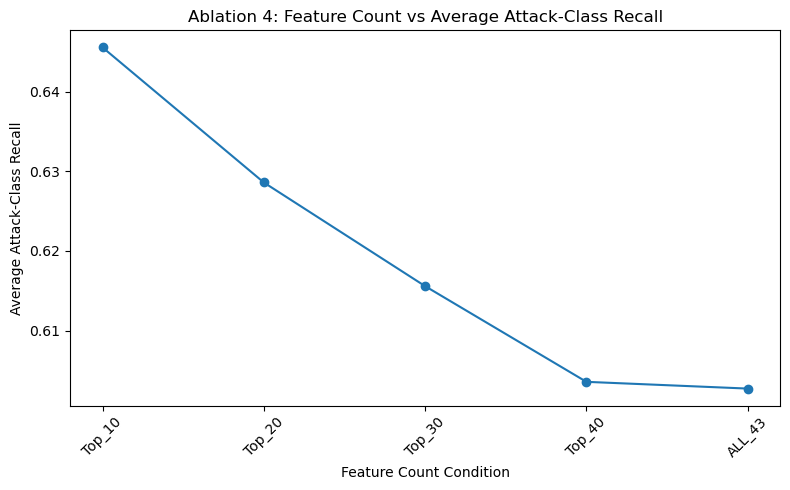

Saved: ..\reports\ablation4_feature_count_recall.png


In [15]:
plot_df = results_df.sort_values("num_features", ascending=True)

plt.figure(figsize=(8, 5))
plt.plot(
    plot_df["feature_count_condition"],
    plot_df["average_attack_recall"],
    marker="o"
)
plt.xlabel("Feature Count Condition")
plt.ylabel("Average Attack-Class Recall")
plt.title("Ablation 4: Feature Count vs Average Attack-Class Recall")
plt.xticks(rotation=45)
plt.tight_layout()

recall_plot_path = REPORT_DIR / "ablation4_feature_count_recall.png"
plt.savefig(recall_plot_path, dpi=300)
plt.show()

print("Saved:", recall_plot_path)

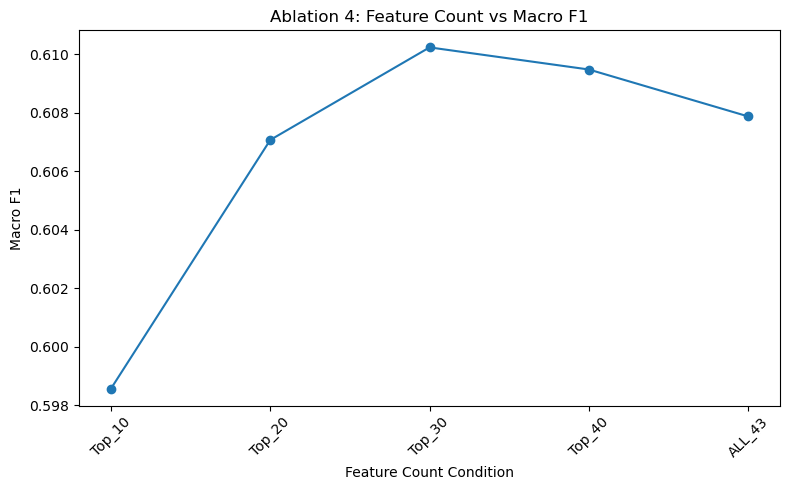

Saved: ..\reports\ablation4_macro_f1.png


In [16]:
plt.figure(figsize=(8, 5))
plt.plot(
    plot_df["feature_count_condition"],
    plot_df["macro_f1"],
    marker="o"
)
plt.xlabel("Feature Count Condition")
plt.ylabel("Macro F1")
plt.title("Ablation 4: Feature Count vs Macro F1")
plt.xticks(rotation=45)
plt.tight_layout()

macro_f1_plot_path = REPORT_DIR / "ablation4_macro_f1.png"
plt.savefig(macro_f1_plot_path, dpi=300)
plt.show()

print("Saved:", macro_f1_plot_path)

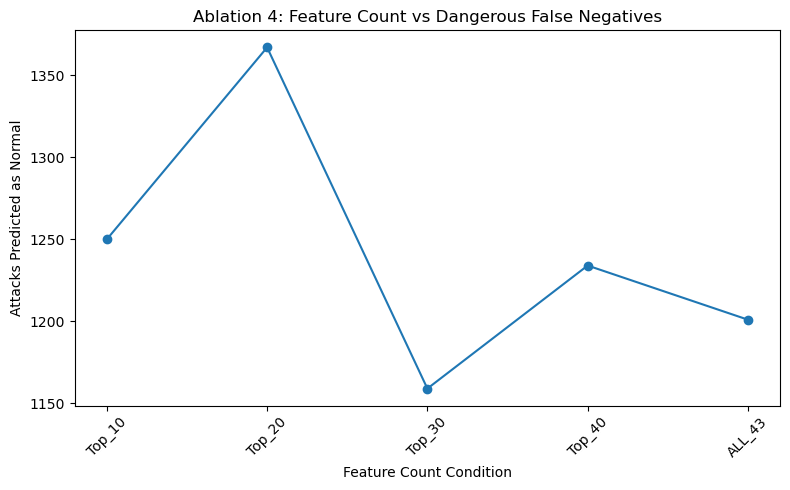

Saved: ..\reports\ablation4_attack_to_normal.png


In [17]:
plt.figure(figsize=(8, 5))
plt.plot(
    plot_df["feature_count_condition"],
    plot_df["attacks_predicted_as_normal"],
    marker="o"
)
plt.xlabel("Feature Count Condition")
plt.ylabel("Attacks Predicted as Normal")
plt.title("Ablation 4: Feature Count vs Dangerous False Negatives")
plt.xticks(rotation=45)
plt.tight_layout()

attack_to_normal_plot_path = REPORT_DIR / "ablation4_attack_to_normal.png"
plt.savefig(attack_to_normal_plot_path, dpi=300)
plt.show()

print("Saved:", attack_to_normal_plot_path)

In [18]:
baseline_row = results_df[
    results_df["feature_count_condition"] == "ALL_43"
].iloc[0]

comparison_df = results_df.copy()

comparison_df["average_attack_recall_delta_vs_all"] = (
    comparison_df["average_attack_recall"]
    - baseline_row["average_attack_recall"]
)

comparison_df["macro_f1_delta_vs_all"] = (
    comparison_df["macro_f1"]
    - baseline_row["macro_f1"]
)

comparison_df["attack_to_normal_delta_vs_all"] = (
    comparison_df["attacks_predicted_as_normal"]
    - baseline_row["attacks_predicted_as_normal"]
)

display(comparison_df)

,feature_count_condition,num_features,feature_selection_method,imbalance_strategy,encoding_strategy,model,average_attack_recall,macro_f1,attacks_predicted_as_normal,selected_features,average_attack_recall_delta_vs_all,macro_f1_delta_vs_all,attack_to_normal_delta_vs_all
0,ALL_43,43,Mutual Information,Capped_SMOTENC_50k,Ordinal Encoding,RandomForestClassifier,0.602726,0.607879,1201,sport|dsport|proto|state|dur|sbytes|dbytes|stt...,0.000000,0.000000,0
1,Top_40,40,Mutual Information,Capped_SMOTENC_50k,Ordinal Encoding,RandomForestClassifier,0.603573,0.609485,1234,sbytes|sload|sttl|smeansz|ct_state_ttl|dsport|...,0.000846,0.001605,33
2,Top_30,30,Mutual Information,Capped_SMOTENC_50k,Ordinal Encoding,RandomForestClassifier,0.615580,0.610241,1159,sbytes|sload|sttl|smeansz|ct_state_ttl|dsport|...,0.012853,0.002361,-42
3,Top_20,20,Mutual Information,Capped_SMOTENC_50k,Ordinal Encoding,RandomForestClassifier,0.628589,0.607076,1367,sbytes|sload|sttl|smeansz|ct_state_ttl|dsport|...,0.025863,-0.000804,166
4,Top_10,10,Mutual Information,Capped_SMOTENC_50k,Ordinal Encoding,RandomForestClassifier,0.645543,0.598569,1250,sbytes|sload|sttl|smeansz|ct_state_ttl|dsport|...,0.042817,-0.009310,49


In [19]:
print("Ablation 4 conclusion")
print("-" * 80)
print(f"Best feature count condition: {BEST_FEATURE_COUNT_CONDITION}")
print(f"Primary metric: Average Attack-Class Recall = {best_feature_count_row['average_attack_recall']:.4f}")
print(f"Secondary metric: Macro F1 = {best_feature_count_row['macro_f1']:.4f}")
print()
print(
    "Final selection is based primarily on Average Attack-Class Recall. "
    "Macro F1 is used only as a secondary tie-breaker."
)

Ablation 4 conclusion
--------------------------------------------------------------------------------
Best feature count condition: Top_10
Primary metric: Average Attack-Class Recall = 0.6455
Secondary metric: Macro F1 = 0.5986

Final selection is based primarily on Average Attack-Class Recall. Macro F1 is used only as a secondary tie-breaker.
